# pyXenium.multimodal Tutorial

## Overview

This notebook follows the renal immune-resistance pilot bundle from canonical RNA + protein loading through joint state annotation, discordance scoring, spatial niches, and branch-level hypotheses.

## Biological question

How do RNA and protein signals combine to reveal immune-resistance niches in renal carcinoma tissue, and which branch-specific programs emerge strongly enough to motivate follow-up validation?


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate the pyXenium repository root.")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 12)


In [2]:
RENAL_DATASET_PATH = Path(
    os.environ.get(
        "PYXENIUM_RENAL_DATASET",
        r"Y:\long\10X_datasets\Xenium\Xenium_Renal\Xenium_V1_Human_Kidney_FFPE_Protein",
    )
)
ARTIFACT_DIR = REPO_ROOT / "manuscript" / "renal_immune_resistance_pilot"
RUN_FULL_ANALYSIS = False

RENAL_DATASET_PATH, ARTIFACT_DIR


(WindowsPath('Y:/long/10X_datasets/Xenium/Xenium_Renal/Xenium_V1_Human_Kidney_FFPE_Protein'),
 WindowsPath('D:/GitHub/pyXenium/manuscript/renal_immune_resistance_pilot'))

## Dataset

- Raw study: 10x Genomics Xenium FFPE human renal carcinoma RNA + protein bundle.
- Versioned outputs: `manuscript/renal_immune_resistance_pilot/`.
- Canonical API: `load_rna_protein_anndata`, `annotate_joint_cell_states`, `compute_rna_protein_discordance`, `build_spatial_niches`, and `score_immune_resistance_program`.

## Setup

The notebook renders the committed renal pilot outputs from a real analysis run and keeps a single rerun cell for regenerating the full pilot locally when the dataset path is available.


In [3]:
payload = json.loads((ARTIFACT_DIR / "summary.json").read_text(encoding="utf-8"))
joint_states = pd.read_csv(ARTIFACT_DIR / "joint_cell_states.csv")
branch_summary = pd.read_csv(ARTIFACT_DIR / "branch_summary.csv")
top_hypotheses = pd.read_csv(ARTIFACT_DIR / "top_hypotheses.csv")

display(joint_states.head(10))
display(branch_summary[["branch", "best_model", "benchmark_score", "held_out_auc"]])
display(top_hypotheses[["branch", "hypothesis", "key_marker", "benchmark_score"]])


,state,n_cells
0,endothelial_perivascular,182783
1,unassigned,64919
2,tumor_epithelial,47704
3,emt_like_tumor,45017
4,t_cell_exhausted_cytotoxic,41864
5,macrophage_like,41765
6,b_plasma_like,41493


,branch,best_model,benchmark_score,held_out_auc
0,epithelial_emt_front,emt_only,0.664316,0.684233
1,myeloid_vascular,vascular_only,0.652438,0.543816


,branch,hypothesis,key_marker,benchmark_score
0,epithelial_emt_front,Checkpoint-active myeloid enrichment at EMT tr...,PanCK,0.664316
1,myeloid_vascular,Perivascular immune-resistance belt,CD163,0.652438


## Core workflow

The renal pilot is intentionally layered: canonical loading first, then increasingly biological summaries built on the same `AnnData` object.

```python
from pyXenium.multimodal import (
    annotate_joint_cell_states,
    build_spatial_niches,
    compute_rna_protein_discordance,
    load_rna_protein_anndata,
    run_renal_immune_resistance_pilot,
    score_immune_resistance_program,
)

adata = load_rna_protein_anndata(str(RENAL_DATASET_PATH), prefer="auto")
state_result = annotate_joint_cell_states(adata)
discordance_result = compute_rna_protein_discordance(adata)
niche_result = build_spatial_niches(adata)
immune_result = score_immune_resistance_program(
    adata,
    discordance_result=discordance_result,
    niche_result=niche_result,
)
```

The packaged shortcut is `run_renal_immune_resistance_pilot(...)`, which is what the rerun cell below uses.


In [4]:
if RUN_FULL_ANALYSIS and RENAL_DATASET_PATH.exists():
    from pyXenium.multimodal import run_renal_immune_resistance_pilot

    study = run_renal_immune_resistance_pilot(
        base_path=str(RENAL_DATASET_PATH),
        output_dir=str(ARTIFACT_DIR),
        export_figures=True,
    )
    display(pd.DataFrame(study["payload"]["top_hypotheses"]))
else:
    display(Markdown("Set `RUN_FULL_ANALYSIS = True` to rerun the renal immune-resistance pilot against the local Xenium bundle."))


Set `RUN_FULL_ANALYSIS = True` to rerun the renal immune-resistance pilot against the local Xenium bundle.

## Visual outputs

The renal pilot makes its biology legible by mapping joint states, niches, and the strongest discordance signal back into tissue space.


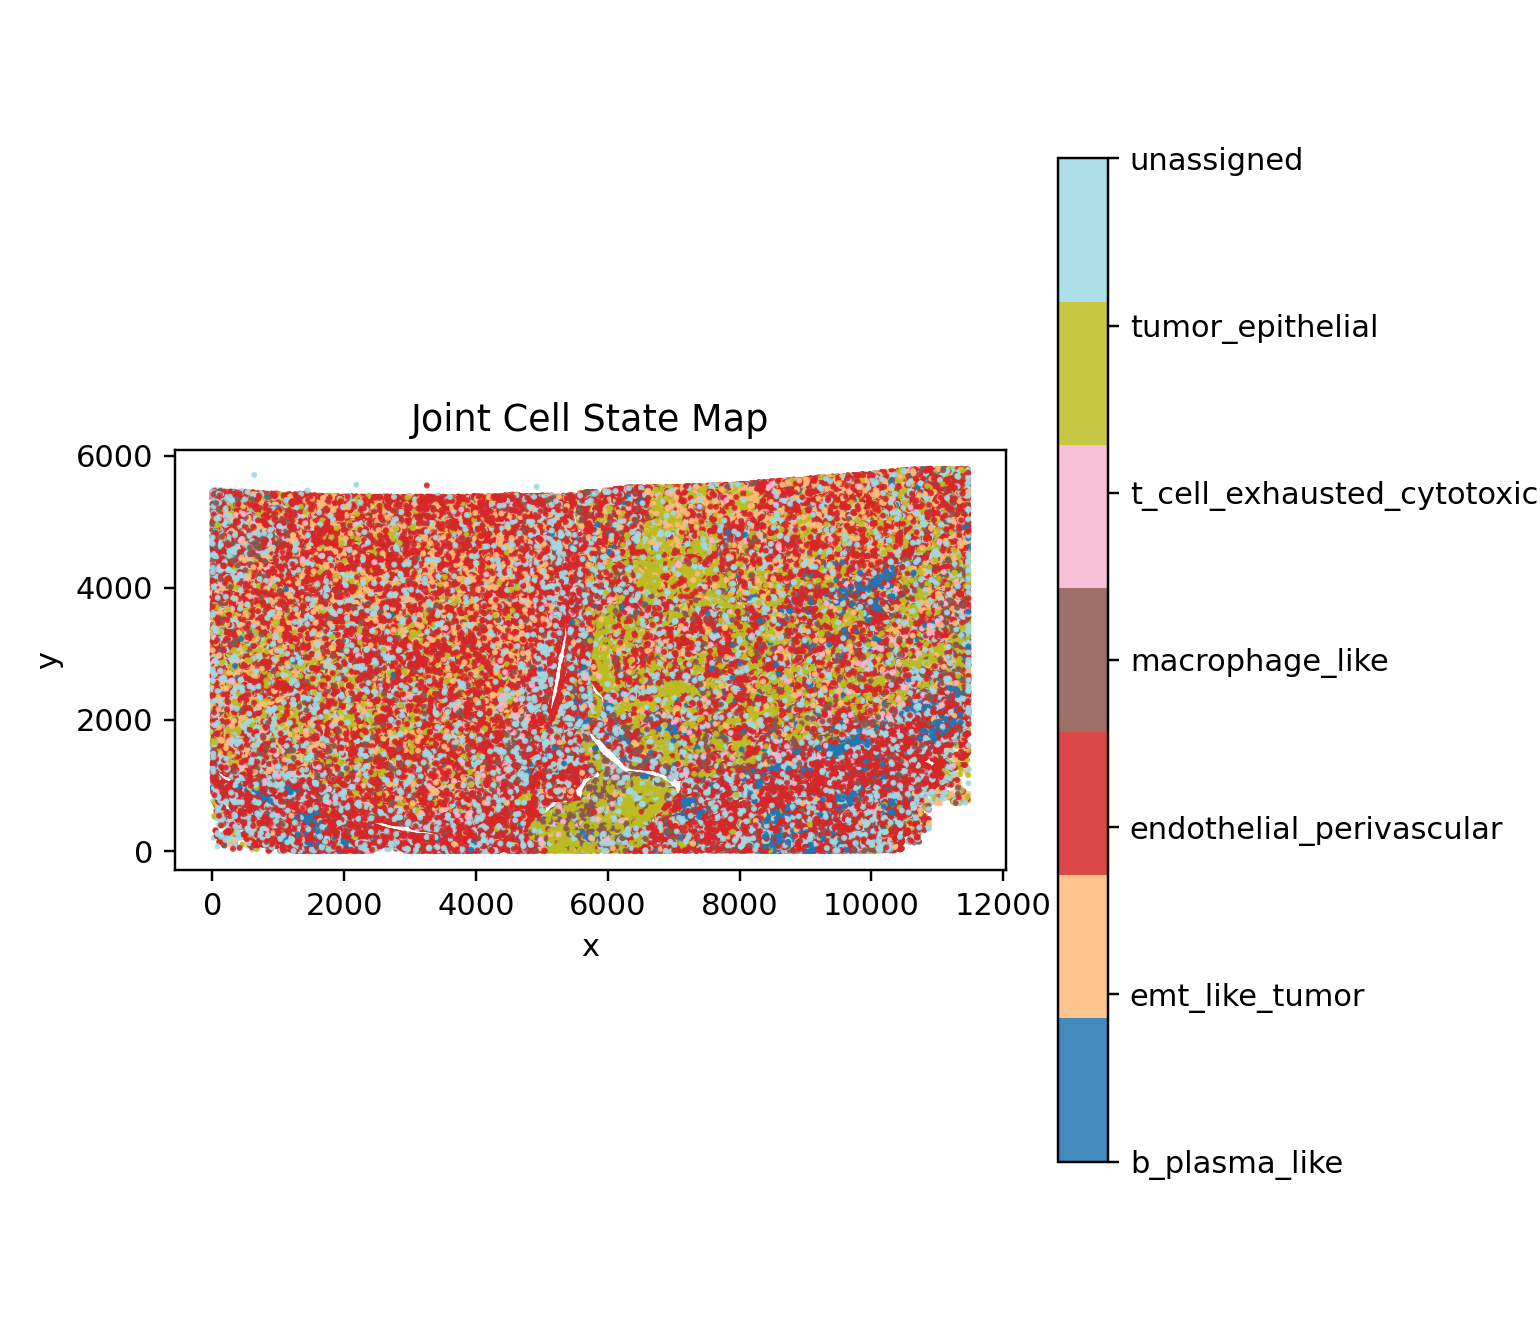

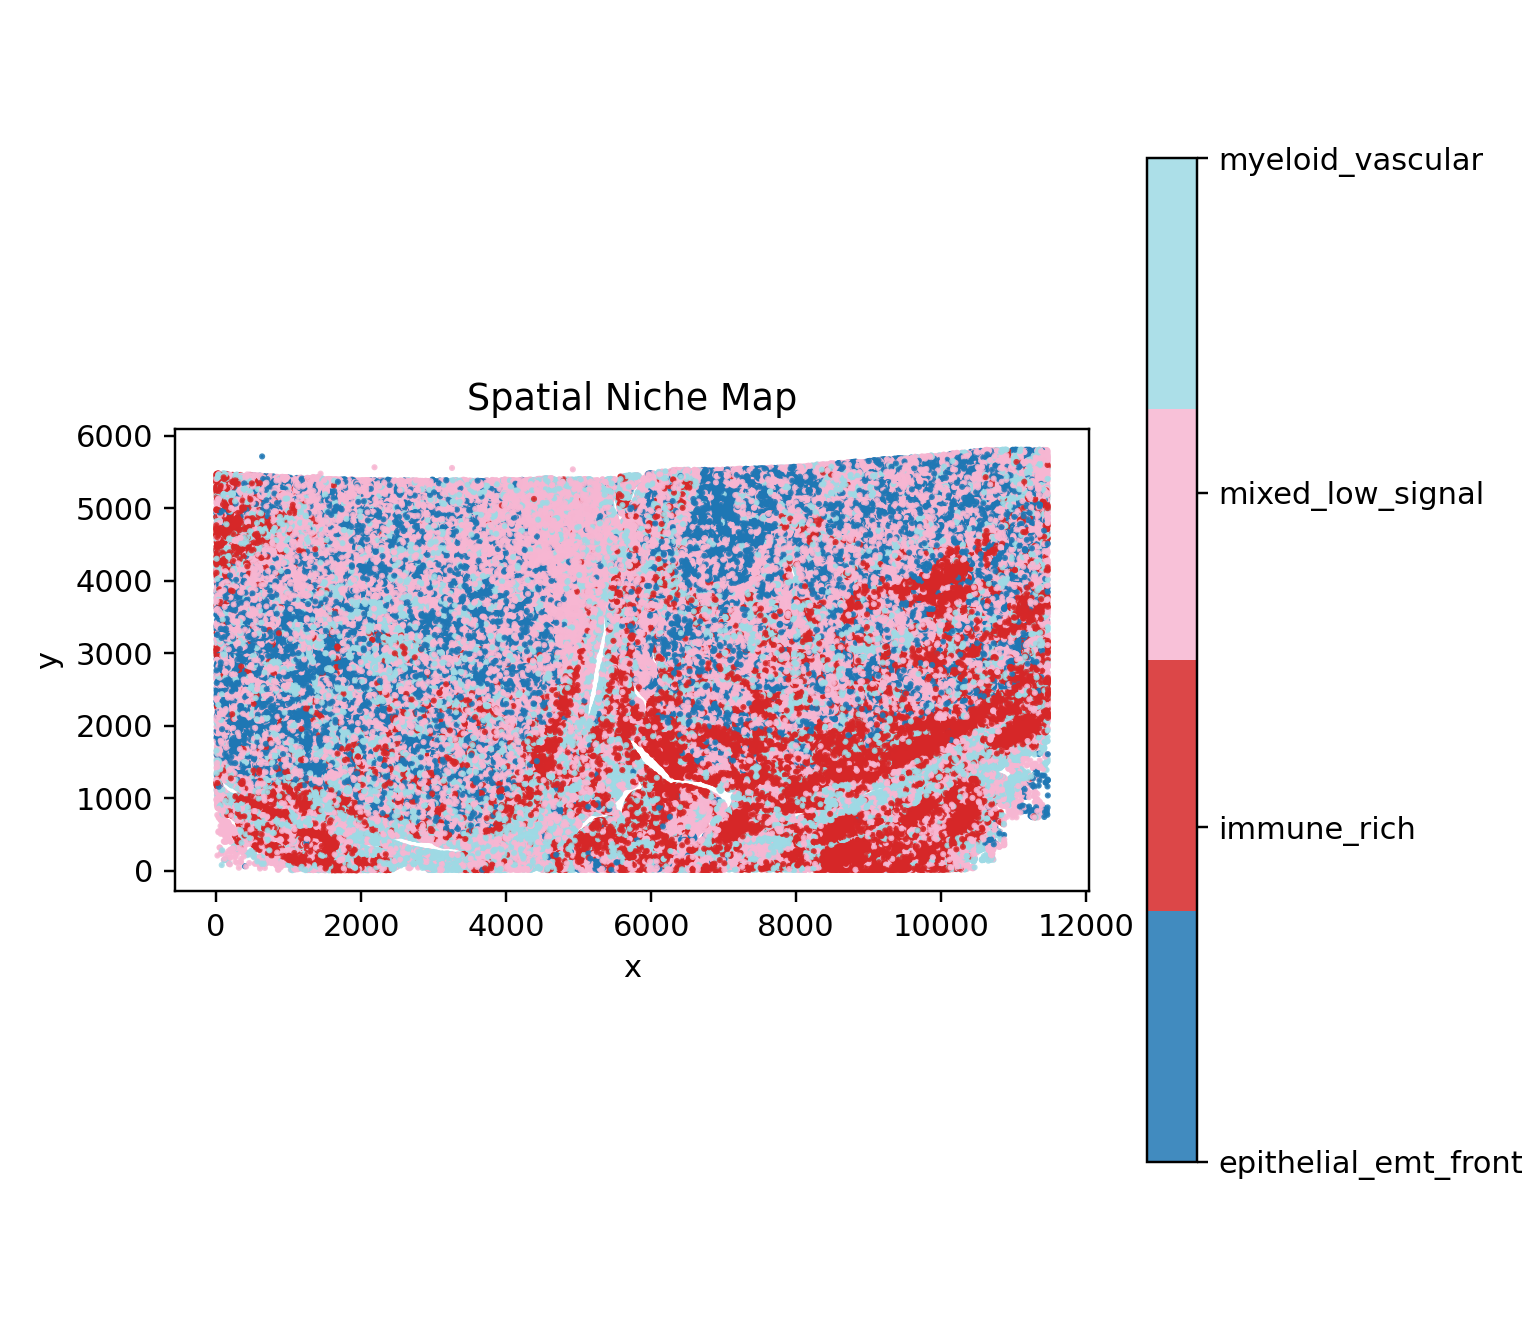

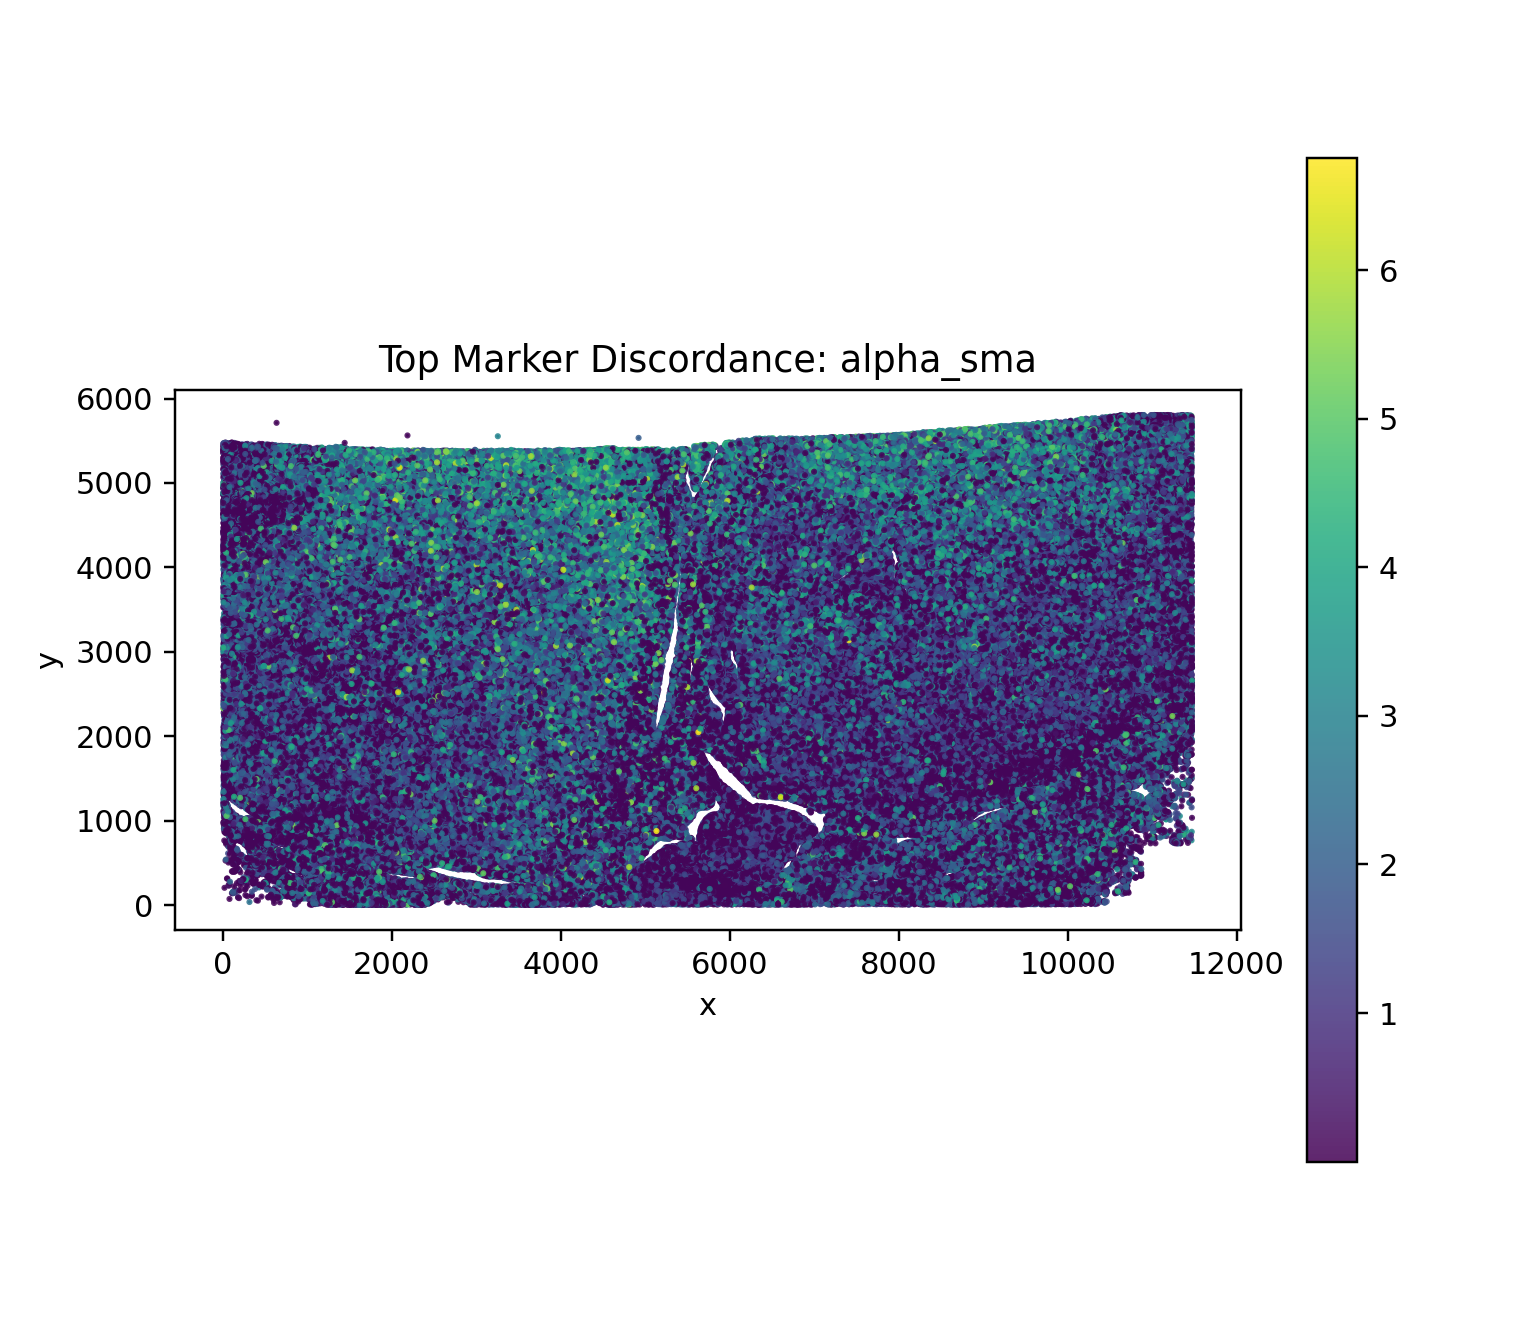

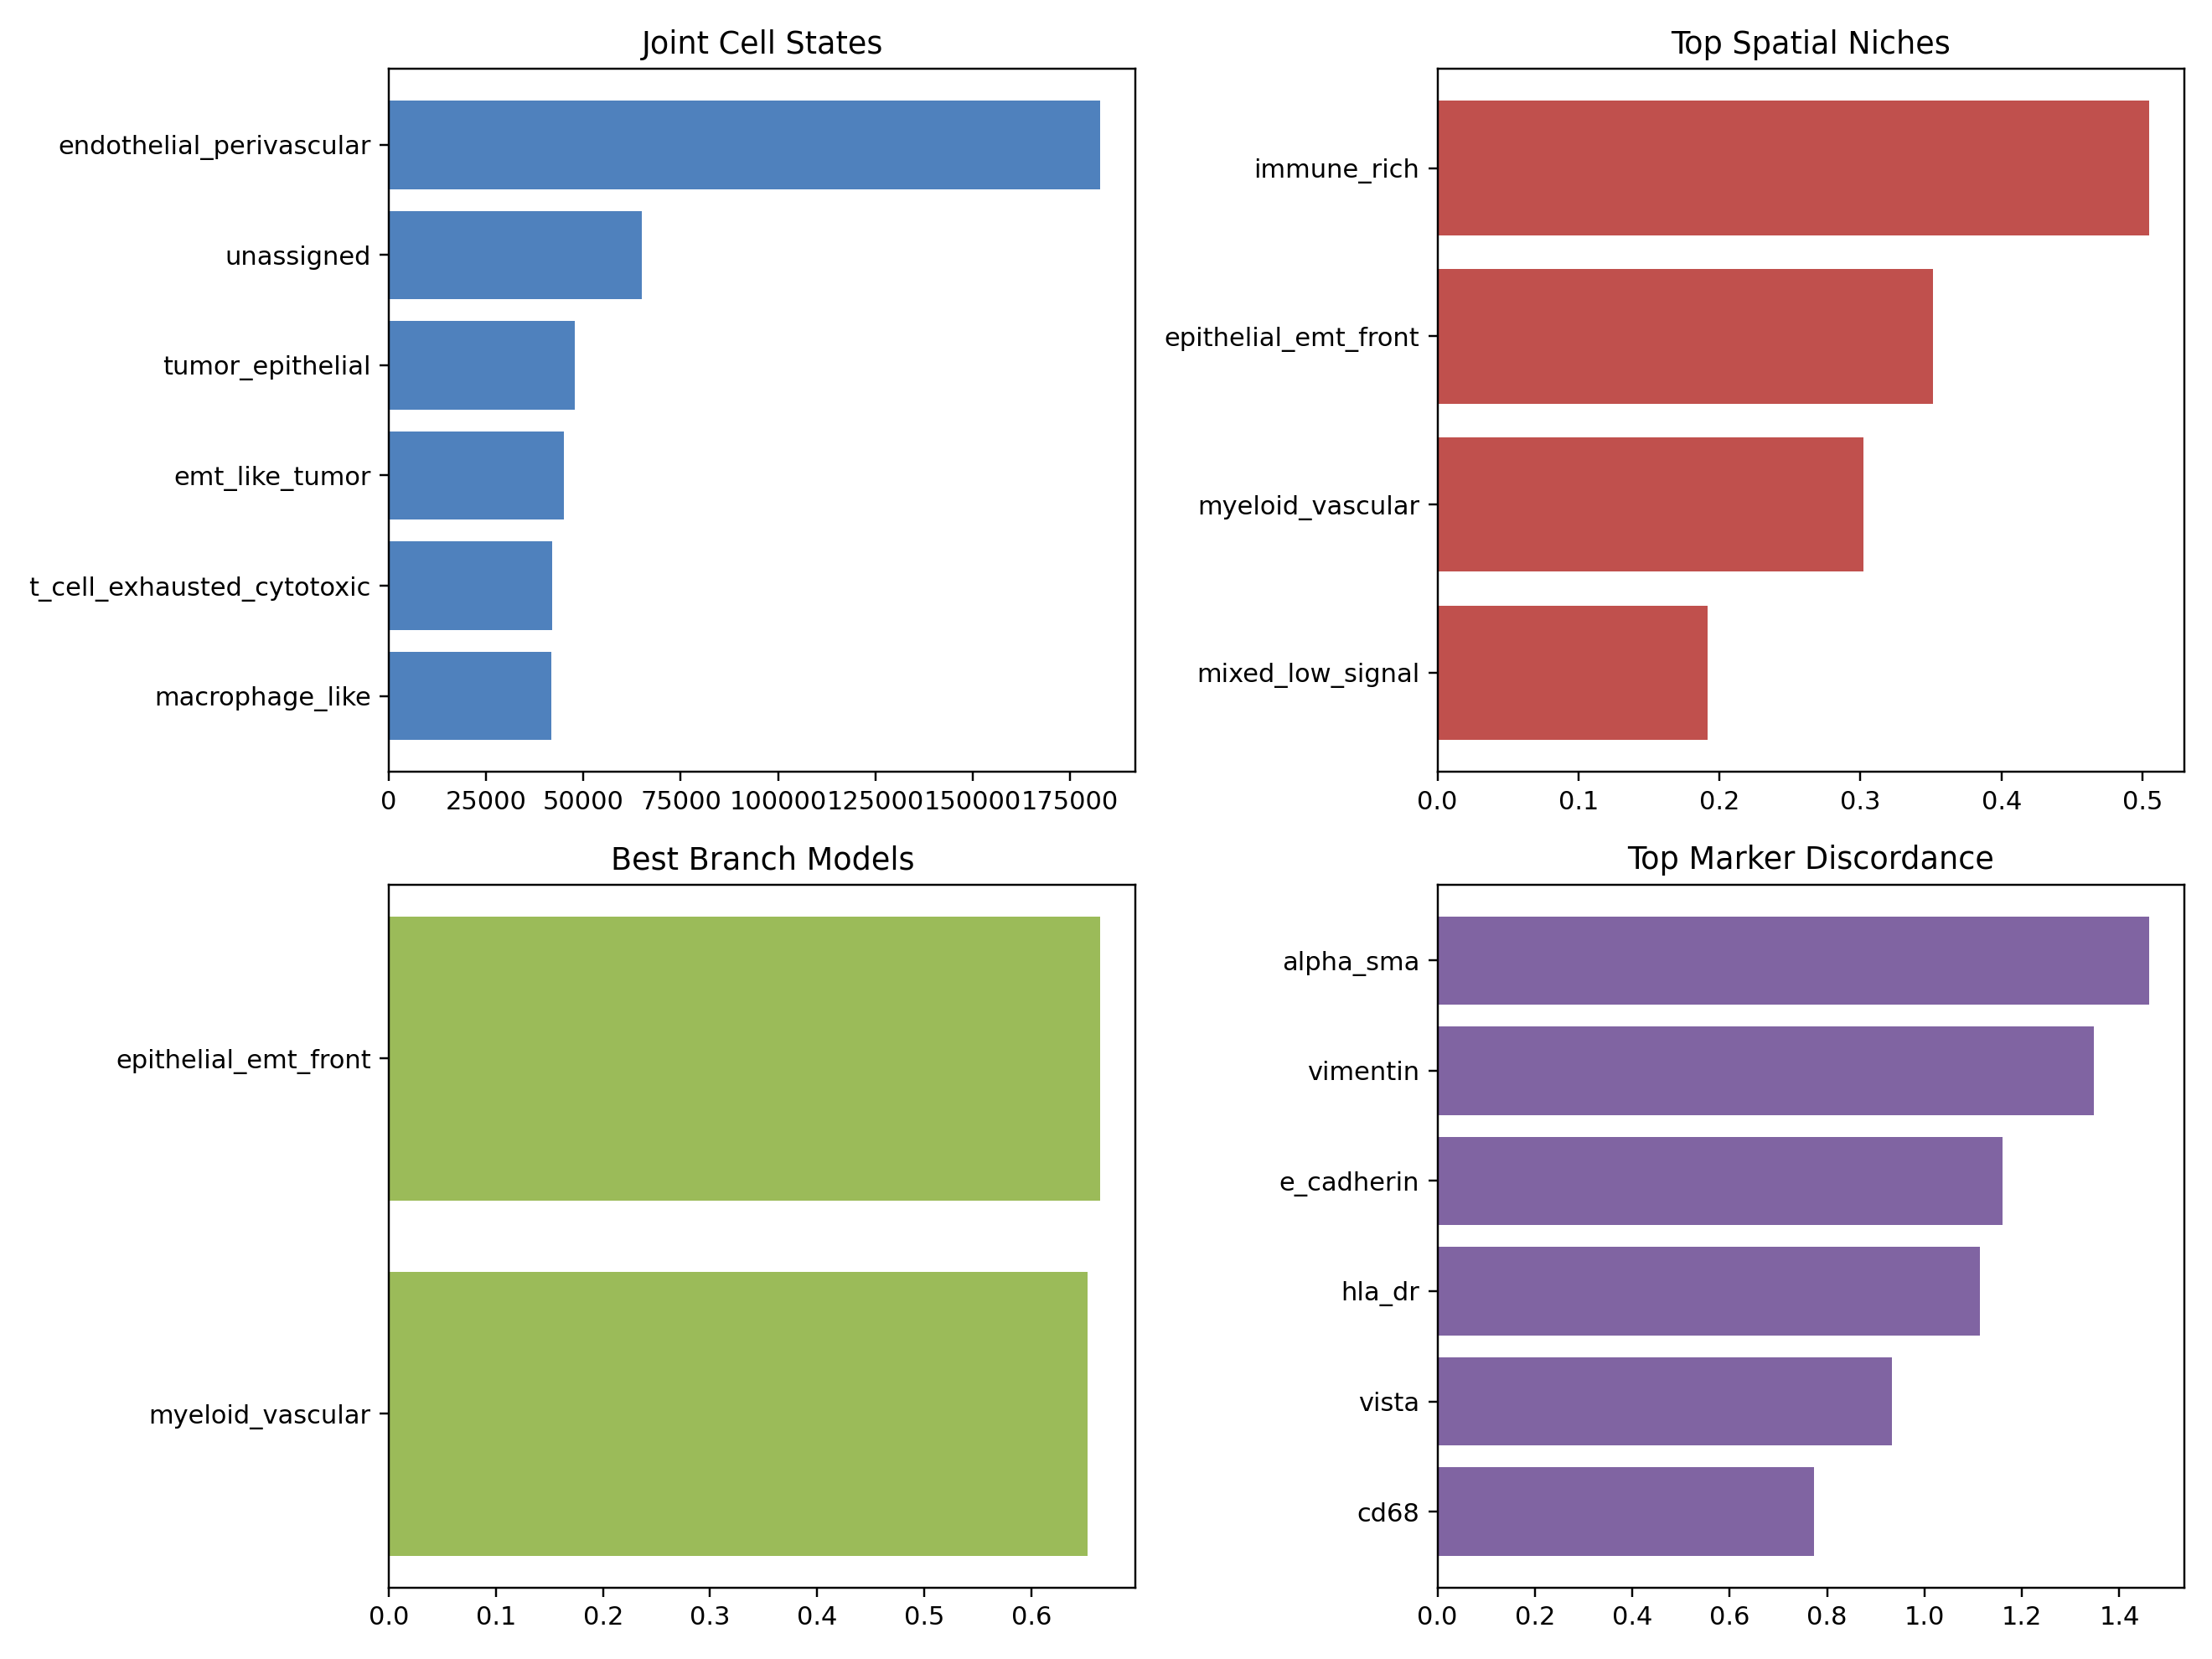

In [5]:
display(Image(filename=str(ARTIFACT_DIR / "figures" / "state_map.png")))
display(Image(filename=str(ARTIFACT_DIR / "figures" / "niche_map.png")))
display(Image(filename=str(ARTIFACT_DIR / "figures" / "top_marker_discordance_map.png")))
display(Image(filename=str(ARTIFACT_DIR / "figures" / "roi_panel_summary.png")))


## Biological interpretation

The renal pilot is designed to surface resistance hypotheses that would be easy to miss in RNA-only or protein-only views. Joint state labels organize the tissue into interpretable cell programs, discordance metrics identify where transcript and protein evidence diverge, and branch-level benchmarking turns those observations into concrete hypotheses such as perivascular immune-resistance belts or checkpoint-active EMT transition fronts.

## Caveats

- This notebook is a single-sample pilot, so the hypotheses are deliberately framed as discovery outputs rather than cohort-level claims.
- Branch benchmarking helps rank mechanisms, but it is not a substitute for orthogonal validation.
- Marker discordance can reflect assay biology, protein stability, spatial mixing, or annotation uncertainty; it should not be overinterpreted from one metric alone.

## Next steps

- Reuse the same loading pattern on additional renal samples before comparing branch-level summaries across a cohort.
- Export the artifact tables for downstream review in pathology, translational, or assay-design workflows.
- Return to the `io` tutorial if you need to understand how the raw Xenium bundle becomes the canonical multimodal `AnnData` used here.
